In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
import pycountry
import openpyxl

### File paths

In [82]:
production_fn = '../../resources/ironore-production.csv'

In [83]:
cost_fn = "../../data/devlin2023-supplementary.xlsx"
cost_sheet_name = "Fig 2b"

In [84]:
iron_ore_map_fn = "../../results/figures_general/iron_ore_map.pdf"

### Workflow

In [85]:
def country_to_iso_a2(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        return None

In [86]:
# %%
# Load OWID iron ore data: https://ourworldindata.org/explorers/minerals?tab=map&Mineral=Iron+ore&Metric=Production&Type=Mine%2C+crude+ore&Share+of+global=false&country=OWID_WRL~AUS~CHL~CHN~USA
df = pd.read_csv("../../data/owid-iron-ore/iron-ore-crude-ore-production.csv")

# Rename columns for easier access
df.rename(columns={
    'Entity': 'Country',
    'Year': 'Year',
    'production|Iron ore|Mine, crude ore|tonnes': 'IronOreProduction',
    'crude ore|tonnes': 'CrudeOreTonnes'
}, inplace=True)

# Keep only rows with available iron ore production data
df = df.dropna(subset=['IronOreProduction'])

# Get latest year per country
df_latest = df.sort_values('Year').groupby('Country', as_index=False).last()

# Drop data that is older than 2010 and drop Country 'World'
df_latest = df_latest[df_latest['Country'] != 'World']
df_latest = df_latest[df_latest['Year'] >= 2010]

# Remove "other"
df_latest = df_latest[df_latest["Country"] != "Other"]

# Map problematic country names to official names for ISO_A2 conversion
country_name_corrections = {
    "Democratic Republic of Congo": "Congo, The Democratic Republic of the",
    "Kosovo": "Republic of Kosovo",  # pycountry not supported
    "Russia": "Russian Federation",
    "Turkey": "Türkiye"
}

df_latest['Country'] = df_latest['Country'].replace(country_name_corrections)
df_latest['ISO_A2'] = df_latest['Country'].apply(country_to_iso_a2)

# Check for any remaining missing ISO_A2 codes
missing_iso_a2 = df_latest[df_latest['ISO_A2'].isna()]
print(f"Countries with missing ISO_A2 codes after correction: {missing_iso_a2['Country'].unique()}")

Countries with missing ISO_A2 codes after correction: []


In [87]:
# Use cartopy to get natural earth countries shapefile
shapename = 'admin_0_countries'
reader = shpreader.natural_earth(resolution='110m',
                                 category='cultural',
                                 name=shapename)

world = gpd.read_file(reader)

# Fix missing ISO_A2 codes in world
if 'ISO_A2' not in world.columns:
    if 'ADMIN' in world.columns:
        world['ISO_A2'] = world['ADMIN'].apply(country_to_iso_a2)
world.loc[world['ISO_A2'] == '-99', 'ISO_A2'] = world.loc[world['ISO_A2'] == '-99', 'ADMIN'].apply(country_to_iso_a2)

# Merge country names — use left join to preserve geometry
merged = world.merge(df_latest, how='left', left_on='ISO_A2', right_on='ISO_A2')

In [88]:
# After merging, filter out rows with missing or zero production
merged = merged[merged['IronOreProduction'].notna() & (merged['IronOreProduction'] > 0)]

In [89]:
# %%
# Convert to megatonnes
merged['IronOreProductionMt'] = merged['IronOreProduction'].divide(1e6) # tonnes to Mt

In [90]:
# Ensure ISO_A2 and IronOreProductionMt exist
filtered_df = merged[
    (merged['IronOreProductionMt'] > 0) & 
    (merged['ISO_A2'].notna())
][['ISO_A2', 'IronOreProductionMt', 'ADMIN']]
# Set ISO_A2 as index
production = filtered_df.set_index('ISO_A2')


### Add cost

In [91]:

# Read iron ore cost data from Devlin 2023 supplementary



# Read the Excel file using openpyxl to get the specific range
wb = openpyxl.load_workbook(cost_fn)
ws = wb[cost_sheet_name]

# Extract country names (A5:A22) and costs (G5:G22)
countries = []
costs = []
for row in range(5, 23):  # A5:A22 is rows 5 to 22
    country = ws[f'A{row}'].value
    cost = ws[f'G{row}'].value
    if country is not None and cost is not None:
        countries.append(country)
        costs.append(cost)

# Create a DataFrame from the cost data
cost_df = pd.DataFrame({
    'Country': countries,
    'IronOreCost': costs
})

# Map country names to ISO_A2 codes (use same corrections as before)
cost_df['Country'] = cost_df['Country'].replace(country_name_corrections)
cost_df['ISO_A2'] = cost_df['Country'].apply(country_to_iso_a2)

### Merge cost and production

In [92]:

# Merge production and cost data
production_cost = production.reset_index()
production_cost = production_cost.merge(
    cost_df[['ISO_A2', 'IronOreCost']], 
    how='left', 
    on='ISO_A2'
)
production_cost = production_cost.set_index('ISO_A2')

production_cost.to_csv(production_fn)

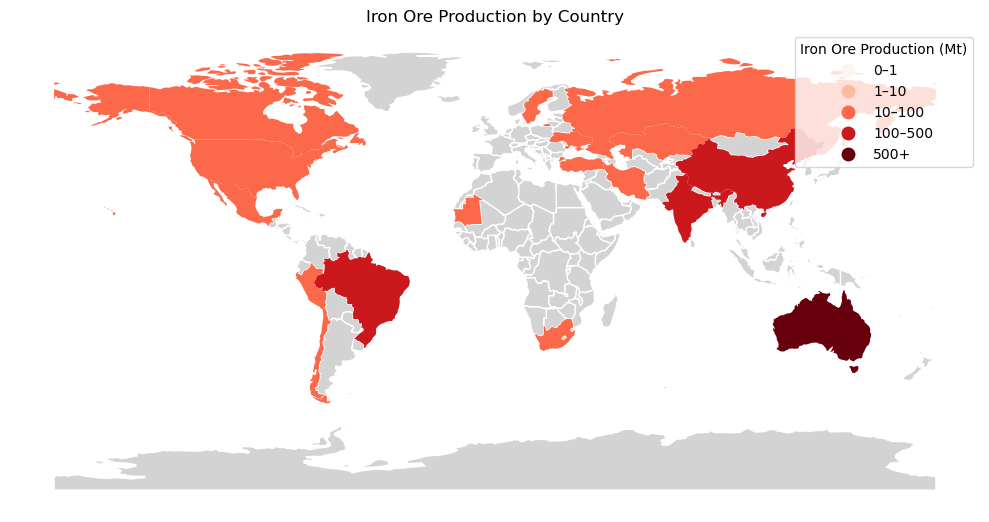

In [93]:

# Define Mt bins and labels
bins = [0, 1, 10, 100, 500, float('inf')]
labels = ['0–1', '1–10', '10–100', '100–500', '500+']

# Bin into categories
merged['ProductionCategory'] = pd.cut(
    merged['IronOreProductionMt'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# %%
# Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Base world map
world.plot(ax=ax, color='lightgrey', edgecolor='white')

# Plot with categorical Mt bins
merged.dropna(subset=['ProductionCategory']).plot(
    ax=ax,
    column='ProductionCategory',
    cmap='Reds',
    legend=True,
    legend_kwds={'title': "Iron Ore Production (Mt)"},
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(f"Iron Ore Production by Country")
ax.axis('off')
plt.tight_layout()
plt.savefig(iron_ore_map_fn)
plt.show()


In [94]:
production_cost.sort_values('IronOreProductionMt', ascending=False)

,IronOreProductionMt,ADMIN,IronOreCost
ISO_A2,,,
AU,960.0,Australia,173.0025
BR,440.0,Brazil,171.9795
CN,280.0,China,174.258
IN,270.0,India,172.6956
RU,88.0,Russia,146.310845
IR,77.0,Iran,149.52
CA,70.0,Canada,175.210683
ZA,61.0,South Africa,171.153231
KZ,53.0,Kazakhstan,315.474231
